In [ ]:
# best model

/home/admin/anaconda3/lib/python3.11/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


Training Accuracy (CatBoost): 0.982
Training Classification Report (CatBoost):
              precision    recall  f1-score   support

           1       0.99      0.95      0.97        87
           2       0.98      0.99      0.99       180
           3       0.98      1.00      0.99        51
           4       1.00      0.90      0.95        10

    accuracy                           0.98       328
   macro avg       0.99      0.96      0.97       328
weighted avg       0.98      0.98      0.98       328

Training Confusion Matrix (CatBoost):
[[ 83   3   1   0]
 [  1 179   0   0]
 [  0   0  51   0]
 [  0   1   0   9]]


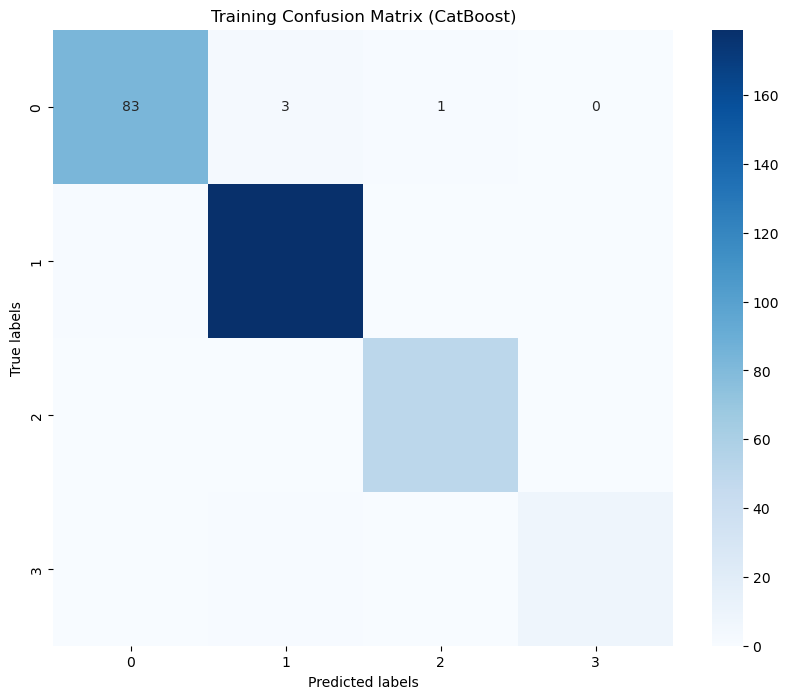

Test Accuracy (CatBoost): 0.566
Test Classification Report (CatBoost):
              precision    recall  f1-score   support

           1       0.68      0.42      0.52        36
           2       0.56      0.69      0.62        35
           3       0.44      1.00      0.62         8
           4       0.00      0.00      0.00         4

    accuracy                           0.57        83
   macro avg       0.42      0.53      0.44        83
weighted avg       0.57      0.57      0.54        83

Test Confusion Matrix (CatBoost):
[[15 18  3  0]
 [ 7 24  4  0]
 [ 0  0  8  0]
 [ 0  1  3  0]]


/home/admin/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/admin/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/admin/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


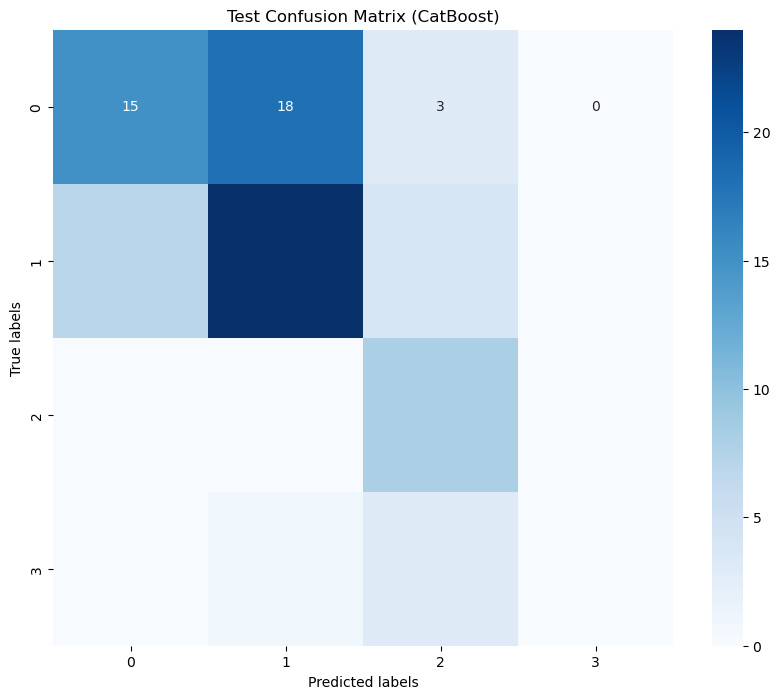

In [1]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load the CSV data
# Load the CSV data
df1 = pd.read_csv('cleaned_x_data_XRDa_featuresNoise.csv')
df2 = pd.read_csv('y_data_kind.csv')

# Split the data into X (features) and y (target)
X = df1 # features (all columns except 'formula' and 'kind')
y = df2['kind']  # target variable 

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a CatBoostClassifier model
cbc = CatBoostClassifier(iterations=500 , verbose=False)
cbc.fit(X_train_scaled, y_train)

# Make predictions on the training and test sets
y_train_pred_cbc = cbc.predict(X_train_scaled)
y_test_pred_cbc = cbc.predict(X_test_scaled)

# Evaluate the model's performance on the training set
accuracy_train_cbc = accuracy_score(y_train, y_train_pred_cbc)
print(f'Training Accuracy (CatBoost): {accuracy_train_cbc:.3f}')

print('Training Classification Report (CatBoost):')
print(classification_report(y_train, y_train_pred_cbc))

print('Training Confusion Matrix (CatBoost):')
print(confusion_matrix(y_train, y_train_pred_cbc))

# Plot the training confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_train, y_train_pred_cbc), annot=True, cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Training Confusion Matrix (CatBoost)')
plt.show()

# Evaluate the model's performance on the test set
accuracy_test_cbc = accuracy_score(y_test, y_test_pred_cbc)
print(f'Test Accuracy (CatBoost): {accuracy_test_cbc:.3f}')

print('Test Classification Report (CatBoost):')
print(classification_report(y_test, y_test_pred_cbc))

print('Test Confusion Matrix (CatBoost):')
print(confusion_matrix(y_test, y_test_pred_cbc))

# Plot the test confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_test_pred_cbc), annot=True, cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Test Confusion Matrix (CatBoost)')
plt.show()

# Save the model to a file
#joblib.dump(cbc, 'cbc_model.joblib')

# Load the peak_intensities_Li_materials.csv data
#peak_intensities_df = pd.read_csv('peak_intensities_Li_materials.csv')

# Scale the data using the same scaler
#peak_intensities_scaled = scaler.transform(peak_intensities_df.drop('formula', axis=1))

# Make predictions on the peak_intensities_Li_materials.csv data
#peak_intensities_pred = cbc.predict(peak_intensities_scaled)

# Save the predictions to a CSV file
#pd.DataFrame({'formula': peak_intensities_df['formula'], 'predicted_kind': peak_intensities_pred}).to_csv('peak_intensities_predictions.csv', index=False)